In [62]:
import pandas as pd

In [63]:
df=pd.read_csv("/content/ai4i2020.csv")

**Data understanding**

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df.duplicated().sum()

**Data Preprocessing**

In [56]:
# Remove unnecessary columns
df = df.drop(columns=["UDI", "Product ID"])

# Convert Type
df["Type"] = df["Type"].map({"L":0, "M":1, "H":2})

# Check class balance
print(df["Machine failure"].value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64


In [57]:
# Feature Engineering

# Feature 1: Temperature Difference
# A machine overheats when the process temperature becomes much higher than the air temperature
df["Temperature Difference"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)

# Feature 2: Mechanical Stress Score
# Machines experience more stress when 1.RPM is high , 2.Torque is high
df["Mechanical Stress"] = (
    df["Rotational speed [rpm]"] *
    df["Torque [Nm]"]
)

# Feature 3: Wear Rate
# Instead of only knowing Tool Wear  ,
# This tells the AI ,How quickly the machine is wearing out relative to its speed.
df["Wear Rate"] = (
    df["Tool wear [min]"] /
    df["Rotational speed [rpm]"]
)

# Save
df.to_csv("processed_ai4i.csv", index=False)

In [58]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Temperature Difference,Mechanical Stress,Wear Rate
0,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,10.5,66382.8,0.000000
1,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,10.5,65190.4,0.002131
2,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,10.4,74001.2,0.003338
3,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,10.4,56603.5,0.004885
4,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,10.5,56320.0,0.006392


Observation: The AI4I dataset is highly imbalanced. Out of 10,000 records, only 339 (3.39%) represent machine failures, while 9,661 (96.61%) represent normal operation. This imbalance may cause the machine learning model to become biased toward predicting normal operation. During model training, imbalance-handling techniques such as SMOTE or class weighting will be considered.





In [4]:
df2=pd.read_csv("/content/cars_dailyRoutes.csv")

/tmp/ipykernel_9854/1073881794.py:1: DtypeWarning: Columns (1,2,4,5,6,9,10,14,15,16,20,21,22,23,24,25,26,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df2=pd.read_csv("/content/cars_dailyRoutes.csv")


In [ ]:
df2.head()

In [ ]:
df2.shape

In [ ]:
df2.info()

In [ ]:
df2.describe()

In [ ]:
df2.isnull().sum()

In [5]:
columns_to_drop = [
    "TIMESTAMP",
    "MARK",
    "MODEL",
    "CAR_YEAR",
    "VEHICLE_ID",
    "DTC_NUMBER",
    "TROUBLE_CODES",
    "MIN",
    "HOURS",
    "DAYS_OF_WEEK",
    "MONTHS",
    "YEAR"
]

df2 = df2.drop(columns=columns_to_drop)

In [6]:
df2.columns

Index(['ENGINE_POWER', 'AUTOMATIC', 'BAROMETRIC_PRESSURE(KPA)',
       'ENGINE_COOLANT_TEMP', 'FUEL_LEVEL', 'ENGINE_LOAD', 'AMBIENT_AIR_TEMP',
       'ENGINE_RPM', 'INTAKE_MANIFOLD_PRESSURE', 'MAF',
       'LONG TERM FUEL TRIM BANK 2', 'FUEL_TYPE', 'AIR_INTAKE_TEMP',
       'FUEL_PRESSURE', 'SPEED', 'SHORT TERM FUEL TRIM BANK 2',
       'SHORT TERM FUEL TRIM BANK 1', 'ENGINE_RUNTIME', 'THROTTLE_POS',
       'TIMING_ADVANCE', 'EQUIV_RATIO'],
      dtype='object')

Clean ENGINE_POWER

In [7]:
df2["ENGINE_POWER"].unique()[:20]

array(['1,4', '1,6', nan, '1', '1,8'], dtype=object)

In [8]:
# Clean ENGINE_POWER
df2["ENGINE_POWER"] = (
    df2["ENGINE_POWER"]
    .str.replace(",",".")
)

df2["ENGINE_POWER"] = pd.to_numeric(
    df2["ENGINE_POWER"],
    errors="coerce"
)

In [9]:
print(df2["ENGINE_POWER"].dtype)
print(df2["ENGINE_POWER"].head())
print(df2["ENGINE_POWER"].isnull().sum())

float64
0    1.4
1    1.4
2    1.4
3    1.4
4    1.4
Name: ENGINE_POWER, dtype: float64
12980


Clean AUTOMATIC

In [10]:
df2["AUTOMATIC"].value_counts(dropna=False)

,count
AUTOMATIC,
n,33956
s,13503
NaN,12980


In [11]:
df2["AUTOMATIC"] = df2["AUTOMATIC"].replace({
    "n": 0,
    "s": 1
})

/tmp/ipykernel_9854/1186244134.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df2["AUTOMATIC"] = df2["AUTOMATIC"].replace({


In [12]:
# Convert to Numeric
df2["AUTOMATIC"] = pd.to_numeric(
    df2["AUTOMATIC"],
    errors="coerce"
)

In [13]:
print(df2["AUTOMATIC"].dtype)
print(df2["AUTOMATIC"].value_counts(dropna=False))

float64
AUTOMATIC
0.0    33956
1.0    13503
NaN    12980
Name: count, dtype: int64


In [14]:
df2.isnull().sum().sort_values(ascending=False)

,0
FUEL_PRESSURE,60301
FUEL_LEVEL,57445
AMBIENT_AIR_TEMP,56820
BAROMETRIC_PRESSURE(KPA),50227
MAF,48611
EQUIV_RATIO,48543
ENGINE_RUNTIME,48537
LONG TERM FUEL TRIM BANK 2,47369
SHORT TERM FUEL TRIM BANK 2,47369
FUEL_TYPE,40434


In [15]:
columns_to_drop = [
    "FUEL_PRESSURE",
    "FUEL_LEVEL",
    "AMBIENT_AIR_TEMP",
    "BAROMETRIC_PRESSURE(KPA)",
    "MAF",
    "EQUIV_RATIO",
    "ENGINE_RUNTIME",
    "LONG TERM FUEL TRIM BANK 2",
    "SHORT TERM FUEL TRIM BANK 2"
]

df2 = df2.drop(columns=columns_to_drop)

In [16]:
print(df2.columns)
print(df2.shape)

Index(['ENGINE_POWER', 'AUTOMATIC', 'ENGINE_COOLANT_TEMP', 'ENGINE_LOAD',
       'ENGINE_RPM', 'INTAKE_MANIFOLD_PRESSURE', 'FUEL_TYPE',
       'AIR_INTAKE_TEMP', 'SPEED', 'SHORT TERM FUEL TRIM BANK 1',
       'THROTTLE_POS', 'TIMING_ADVANCE'],
      dtype='object')
(60439, 12)


In [17]:
# Duplicate Rows
df2.duplicated().sum()

np.int64(26042)

In [18]:
# Remove Duplicate Rows
df2 = df2.drop_duplicates()

In [19]:
print(df2.shape)
print(df2.duplicated().sum())

(34397, 12)
0


**Cleaning ENGINE_LOAD**

In [20]:
print(df2["ENGINE_LOAD"].dtype)

print(df2["ENGINE_LOAD"].head(10))

print(df2["ENGINE_LOAD"].unique()[:20])

object
0    33,30%
1    32,50%
2    32,90%
3    32,50%
4    32,90%
5    32,90%
6    33,30%
7    33,30%
8    33,30%
9    32,90%
Name: ENGINE_LOAD, dtype: object
['33,30%' '32,50%' '32,90%' '34,50%' '34,10%' '34,90%' '37,30%' '26,70%'
 '36,90%' '29,40%' '36,50%' '31,00%' '32,20%' '30,20%' '29,00%' '29,80%'
 '31,40%' '30,60%' '25,50%' '27,10%']


In [21]:
# Remove %
df2["ENGINE_LOAD"] = df2["ENGINE_LOAD"].astype(str).str.replace("%", "", regex=False)

# Replace comma with decimal point
df2["ENGINE_LOAD"] = df2["ENGINE_LOAD"].str.replace(",", ".", regex=False)

# Convert to numeric
df2["ENGINE_LOAD"] = pd.to_numeric(
    df2["ENGINE_LOAD"],
    errors="coerce"
)

In [22]:
print(df2["ENGINE_LOAD"].dtype)
print(df2["ENGINE_LOAD"].head())
print(df2["ENGINE_LOAD"].isnull().sum())

float64
0    33.3
1    32.5
2    32.9
3    32.5
4    32.9
Name: ENGINE_LOAD, dtype: float64
3523


Cleaning ENGINE_COOLANT_TEMP

In [23]:
print(df2["ENGINE_COOLANT_TEMP"].dtype)

print(df2["ENGINE_COOLANT_TEMP"].head(10))

print(df2["ENGINE_COOLANT_TEMP"].describe())

print(df2["ENGINE_COOLANT_TEMP"].isnull().sum())

float64
0    80.0
1    80.0
2    80.0
3    80.0
4    80.0
5    81.0
6    81.0
7    81.0
8    81.0
9    81.0
Name: ENGINE_COOLANT_TEMP, dtype: float64
count    33740.000000
mean        81.734262
std         10.902666
min         22.000000
25%         78.000000
50%         85.000000
75%         88.000000
max        105.000000
Name: ENGINE_COOLANT_TEMP, dtype: float64
657


Next Column: ENGINE_RPM

In [24]:
print(df2["ENGINE_RPM"].dtype)

print(df2["ENGINE_RPM"].head(10))

print(df2["ENGINE_RPM"].describe())

print(df2["ENGINE_RPM"].isnull().sum())

float64
0    1009.0
1    1003.0
2     995.0
3    1004.0
4    1005.0
5    1019.0
6    1002.0
7    1001.0
8    1004.0
9    1010.0
Name: ENGINE_RPM, dtype: float64
count    33858.000000
mean      1517.825802
std        613.932718
min        438.000000
25%        906.000000
50%       1487.000000
75%       1957.000000
max       3816.000000
Name: ENGINE_RPM, dtype: float64
539


Next Column: INTAKE_MANIFOLD_PRESSURE

In [25]:
print(df2["INTAKE_MANIFOLD_PRESSURE"].dtype)

print(df2["INTAKE_MANIFOLD_PRESSURE"].head(10))

print(df2["INTAKE_MANIFOLD_PRESSURE"].describe())

print(df2["INTAKE_MANIFOLD_PRESSURE"].isnull().sum())

float64
0    49.0
1    52.0
2    51.0
3    51.0
4    49.0
5    50.0
6    49.0
7    50.0
8    52.0
9    52.0
Name: INTAKE_MANIFOLD_PRESSURE, dtype: float64
count    24880.000000
mean        46.936897
std         19.693855
min         13.000000
25%         31.000000
50%         43.000000
75%         57.000000
max        101.000000
Name: INTAKE_MANIFOLD_PRESSURE, dtype: float64
9517


Next Column: FUEL_TYPE

In [26]:
print(df2["FUEL_TYPE"].dtype)

print(df2["FUEL_TYPE"].value_counts(dropna=False))

object
FUEL_TYPE
NaN                   25217
Biodiesel_Ethanol      9042
Biodiesel_Gasoline      138
Name: count, dtype: int64


Next Column:AIR_INTAKE_TEMP

In [27]:
print("="*60)
print("AIR_INTAKE_TEMP")
print(df2["AIR_INTAKE_TEMP"].dtype)
print(df2["AIR_INTAKE_TEMP"].head())
print(df2["AIR_INTAKE_TEMP"].describe())
print("Missing values:", df2["AIR_INTAKE_TEMP"].isnull().sum())

AIR_INTAKE_TEMP
float64
0    59.0
1    59.0
2    59.0
3    60.0
4    60.0
Name: AIR_INTAKE_TEMP, dtype: float64
count    34128.000000
mean        41.197492
std          8.514954
min         23.000000
25%         35.000000
50%         40.000000
75%         47.000000
max         80.000000
Name: AIR_INTAKE_TEMP, dtype: float64
Missing values: 269


Next Column: SHORT TERM FUEL TRIM BANK 1



In [28]:
print("="*60)
print("SHORT TERM FUEL TRIM BANK 1")
print(df2["SHORT TERM FUEL TRIM BANK 1"].dtype)
print(df2["SHORT TERM FUEL TRIM BANK 1"].head())
print(df2["SHORT TERM FUEL TRIM BANK 1"].unique()[:20])
print("Missing values:", df2["SHORT TERM FUEL TRIM BANK 1"].isnull().sum())

SHORT TERM FUEL TRIM BANK 1
object
0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
Name: SHORT TERM FUEL TRIM BANK 1, dtype: object
[nan '-100%' '2%' '0%' '-4%' '-2%' '-10%' '6%' '1%' '8%' '-1%' '5%' '7%'
 '4%' '3%' '-5%' '-3%' '-6%' '-7%' '-8%']
Missing values: 9412


Next Column: SPEED

In [29]:
print("="*60)
print("SPEED")
print(df2["SPEED"].dtype)
print(df2["SPEED"].head())
print(df2["SPEED"].describe())
print("Missing values:", df2["SPEED"].isnull().sum())

SPEED
float64
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: SPEED, dtype: float64
count    33766.000000
mean        34.096488
std         29.387190
min          0.000000
25%          8.000000
50%         30.000000
75%         51.000000
max        143.000000
Name: SPEED, dtype: float64
Missing values: 631


Next Column: THROTTLE_POS

In [30]:
print("="*60)
print("THROTTLE_POS")
print(df2["THROTTLE_POS"].dtype)
print(df2["THROTTLE_POS"].head())
print(df2["THROTTLE_POS"].unique()[:20])
print("Missing values:", df2["THROTTLE_POS"].isnull().sum())

THROTTLE_POS
object
0    25%
1    25%
2    25%
3    25%
4    25%
Name: THROTTLE_POS, dtype: object
['25%' '26%' '22%' '32%' '24%' '27%' '30%' '33%' '29%' '23%' '31%' '28%'
 '35%' '45%' '21%' nan '84%' '34%' '37%' '53%']
Missing values: 773


Next Column: TIMING_ADVANCE

In [31]:
print("="*60)
print("TIMING_ADVANCE")
print(df2["TIMING_ADVANCE"].dtype)
print(df2["TIMING_ADVANCE"].head())
print(df2["TIMING_ADVANCE"].unique()[:20])
print("Missing values:", df2["TIMING_ADVANCE"].isnull().sum())

TIMING_ADVANCE
object
0    56,9%
1    56,5%
2    57,3%
3    56,5%
4    56,9%
Name: TIMING_ADVANCE, dtype: object
['56,9%' '56,5%' '57,3%' '58,4%' '55,7%' '56,1%' '60,0%' '77,6%' '53,7%'
 '54,9%' '59,6%' '53,3%' '58,8%' '58,0%' '57,6%' '71,4%' '55,3%' '48,6%'
 '51,8%' '67,5%']
Missing values: 463


In [33]:
def clean_percentage_column(df, column):
    df[column] = (
        df[column]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    df[column] = pd.to_numeric(df[column], errors="coerce")

    return df

In [34]:
cols = [
    "SHORT TERM FUEL TRIM BANK 1",
    "THROTTLE_POS",
    "TIMING_ADVANCE"
]

for col in cols:
    df2 = clean_percentage_column(df2, col)

In [35]:
for col in cols:
    print("="*50)
    print(col)
    print(df2[col].dtype)
    print(df2[col].head())
    print("Missing:", df2[col].isnull().sum())

SHORT TERM FUEL TRIM BANK 1
float64
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: SHORT TERM FUEL TRIM BANK 1, dtype: float64
Missing: 9412
THROTTLE_POS
float64
0    25.0
1    25.0
2    25.0
3    25.0
4    25.0
Name: THROTTLE_POS, dtype: float64
Missing: 773
TIMING_ADVANCE
float64
0    56.9
1    56.5
2    57.3
3    56.5
4    56.9
Name: TIMING_ADVANCE, dtype: float64
Missing: 463


In [36]:
df2.isnull().sum().sort_values(ascending=False)

,0
FUEL_TYPE,25217
INTAKE_MANIFOLD_PRESSURE,9517
SHORT TERM FUEL TRIM BANK 1,9412
ENGINE_LOAD,3523
THROTTLE_POS,773
ENGINE_COOLANT_TEMP,657
SPEED,631
ENGINE_RPM,539
TIMING_ADVANCE,463
AIR_INTAKE_TEMP,269


In [37]:
numeric_cols = [
    "ENGINE_POWER",
    "ENGINE_COOLANT_TEMP",
    "ENGINE_LOAD",
    "ENGINE_RPM",
    "INTAKE_MANIFOLD_PRESSURE",
    "AIR_INTAKE_TEMP",
    "SPEED",
    "SHORT TERM FUEL TRIM BANK 1",
    "THROTTLE_POS",
    "TIMING_ADVANCE"
]

for col in numeric_cols:
    df2[col] = df2[col].fillna(df2[col].median())

In [38]:
categorical_cols = [
    "AUTOMATIC",
    "FUEL_TYPE"
]

for col in categorical_cols:
    df2[col] = df2[col].fillna(df2[col].mode()[0])

In [39]:
print(df2["FUEL_TYPE"].value_counts())

FUEL_TYPE
Biodiesel_Ethanol     34259
Biodiesel_Gasoline      138
Name: count, dtype: int64


In [40]:
fuel_map = {
    "Biodiesel_Ethanol": 0,
    "Biodiesel_Gasoline": 1
}

df2["FUEL_TYPE"] = df2["FUEL_TYPE"].map(fuel_map)

In [41]:
print(df2.info())
print("\nMissing Values:\n")
print(df2.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 34397 entries, 0 to 47514
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ENGINE_POWER                 34397 non-null  float64
 1   AUTOMATIC                    34397 non-null  float64
 2   ENGINE_COOLANT_TEMP          34397 non-null  float64
 3   ENGINE_LOAD                  34397 non-null  float64
 4   ENGINE_RPM                   34397 non-null  float64
 5   INTAKE_MANIFOLD_PRESSURE     34397 non-null  float64
 6   FUEL_TYPE                    34397 non-null  int64  
 7   AIR_INTAKE_TEMP              34397 non-null  float64
 8   SPEED                        34397 non-null  float64
 9   SHORT TERM FUEL TRIM BANK 1  34397 non-null  float64
 10  THROTTLE_POS                 34397 non-null  float64
 11  TIMING_ADVANCE               34397 non-null  float64
dtypes: float64(11), int64(1)
memory usage: 3.4 MB
None

Missing Values:

ENGINE_POW

6 engineered features

In [42]:
df2["ENGINE_STRESS_INDEX"] = (
    df2["ENGINE_RPM"] *
    df2["ENGINE_LOAD"]
)

In [43]:
df2["THERMAL_STRESS"] = (
    df2["ENGINE_COOLANT_TEMP"] -
    df2["AIR_INTAKE_TEMP"]
)

In [44]:
df2["DRIVING_SCORE"] = (
    df2["ENGINE_LOAD"] +
    df2["THROTTLE_POS"]
) * df2["SPEED"]

In [45]:
df2["AIR_FLOW_INDEX"] = (
    df2["INTAKE_MANIFOLD_PRESSURE"] /
    (df2["ENGINE_RPM"] + 1)
)

In [46]:
df2["ENGINE_EFFICIENCY"] = (
    df2["TIMING_ADVANCE"] /
    (df2["ENGINE_LOAD"] + 1)
)

In [47]:
df2["IRSI"] = (
      0.35*df2["ENGINE_LOAD"]
    + 0.30*df2["THROTTLE_POS"]
    + 0.20*df2["ENGINE_RPM"]/100
    + 0.15*df2["SPEED"]
)

In [48]:
df2.head()

,ENGINE_POWER,AUTOMATIC,ENGINE_COOLANT_TEMP,ENGINE_LOAD,ENGINE_RPM,INTAKE_MANIFOLD_PRESSURE,FUEL_TYPE,AIR_INTAKE_TEMP,SPEED,SHORT TERM FUEL TRIM BANK 1,THROTTLE_POS,TIMING_ADVANCE,ENGINE_STRESS_INDEX,THERMAL_STRESS,DRIVING_SCORE,AIR_FLOW_INDEX,ENGINE_EFFICIENCY,IRSI
0,1.4,0.0,80.0,33.3,1009.0,49.0,0,59.0,0.0,0.0,25.0,56.9,33599.7,21.0,0.0,0.048515,1.658892,21.173
1,1.4,0.0,80.0,32.5,1003.0,52.0,0,59.0,0.0,0.0,25.0,56.5,32597.5,21.0,0.0,0.051793,1.686567,20.881
2,1.4,0.0,80.0,32.9,995.0,51.0,0,59.0,0.0,0.0,25.0,57.3,32735.5,21.0,0.0,0.051205,1.690265,21.005
3,1.4,0.0,80.0,32.5,1004.0,51.0,0,60.0,0.0,0.0,25.0,56.5,32630.0,20.0,0.0,0.050746,1.686567,20.883
4,1.4,0.0,80.0,32.9,1005.0,49.0,0,60.0,0.0,0.0,25.0,56.9,33064.5,20.0,0.0,0.048708,1.678466,21.025


In [49]:
df2.shape

(34397, 18)

In [50]:
df2.describe()

,ENGINE_POWER,AUTOMATIC,ENGINE_COOLANT_TEMP,ENGINE_LOAD,ENGINE_RPM,INTAKE_MANIFOLD_PRESSURE,FUEL_TYPE,AIR_INTAKE_TEMP,SPEED,SHORT TERM FUEL TRIM BANK 1,THROTTLE_POS,TIMING_ADVANCE,ENGINE_STRESS_INDEX,THERMAL_STRESS,DRIVING_SCORE,AIR_FLOW_INDEX,ENGINE_EFFICIENCY,IRSI
count,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000,34397.000000
mean,1.539972,0.378289,81.796639,40.116859,1517.342762,45.847632,0.004012,41.188127,34.021339,-2.015699,17.959706,55.006902,64417.493796,40.608512,2269.468326,0.035457,1.701292,27.566699
std,0.231081,0.484967,10.807286,20.117951,609.115462,16.841512,0.063214,8.482248,29.121575,29.737667,8.809925,17.637224,52413.621303,10.226545,2709.550631,0.018692,1.259876,11.698936
min,1.000000,0.000000,22.000000,5.100000,438.000000,13.000000,0.000000,23.000000,0.000000,-100.000000,1.000000,0.400000,3060.000000,-9.000000,0.000000,0.005137,0.010152,4.125000
25%,1.400000,0.000000,78.000000,27.500000,910.000000,35.000000,0.000000,35.000000,8.000000,-2.000000,13.000000,49.800000,30419.200000,34.000000,332.400000,0.020520,1.041193,19.648000
50%,1.600000,0.000000,85.000000,38.400000,1487.000000,43.000000,0.000000,40.000000,30.000000,0.000000,18.000000,58.400000,41392.000000,41.000000,1434.800000,0.032058,1.428571,24.130000
75%,1.600000,1.000000,88.000000,45.900000,1950.000000,50.000000,0.000000,47.000000,51.000000,1.000000,23.000000,67.500000,82824.000000,49.000000,3060.000000,0.047013,1.946667,33.119000
max,1.800000,1.000000,105.000000,100.000000,3816.000000,101.000000,1.000000,80.000000,143.000000,99.000000,87.000000,87.800000,365000.000000,74.000000,21009.000000,0.165480,12.721311,77.800000


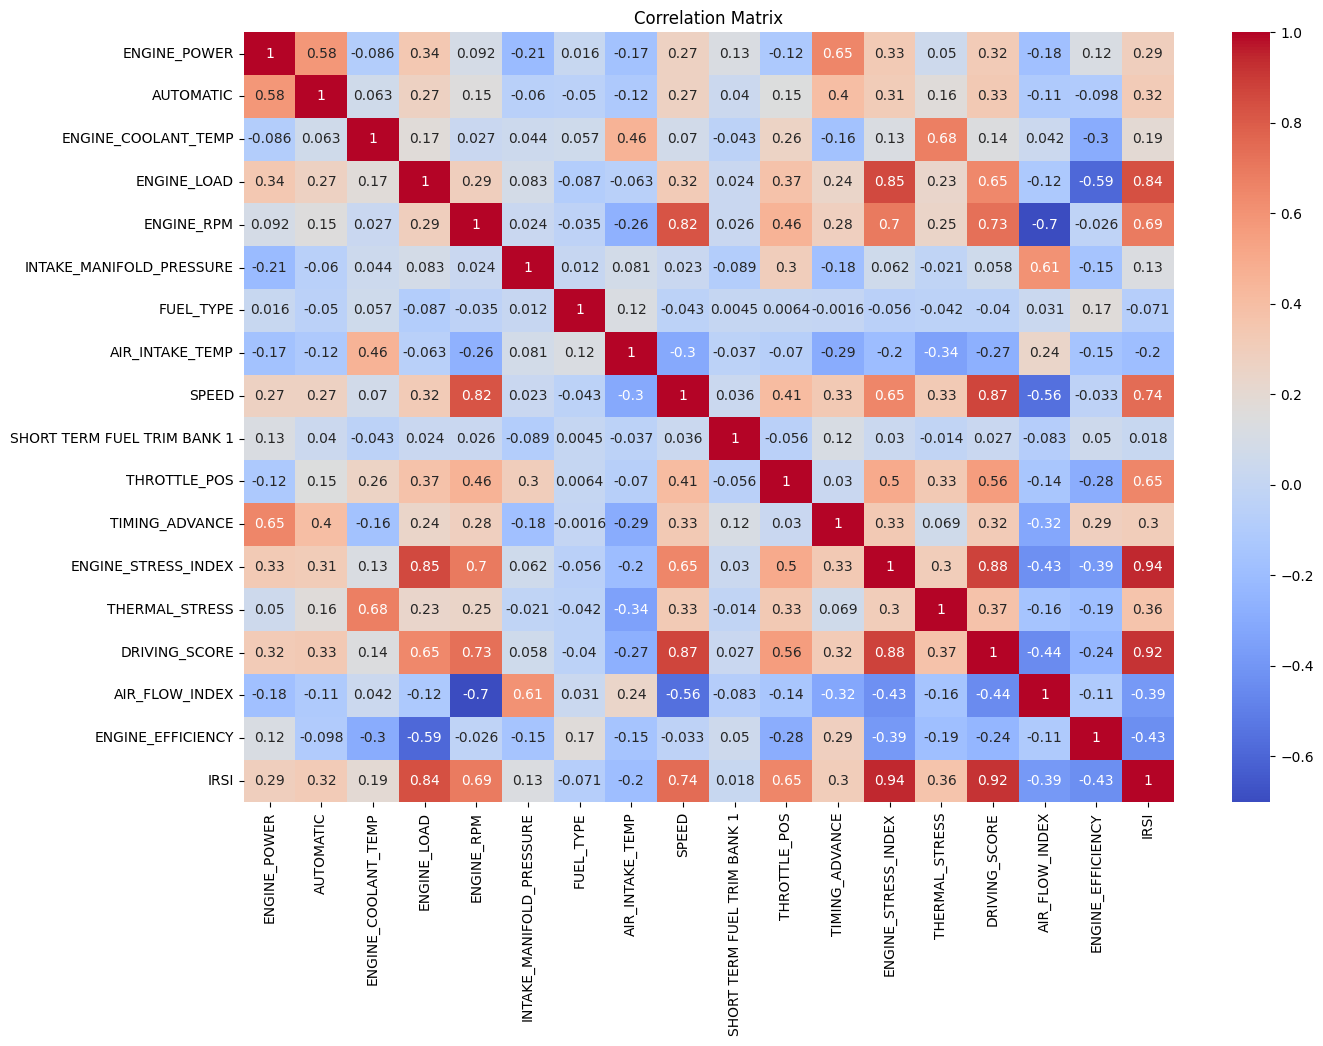

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))
sns.heatmap(df2.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

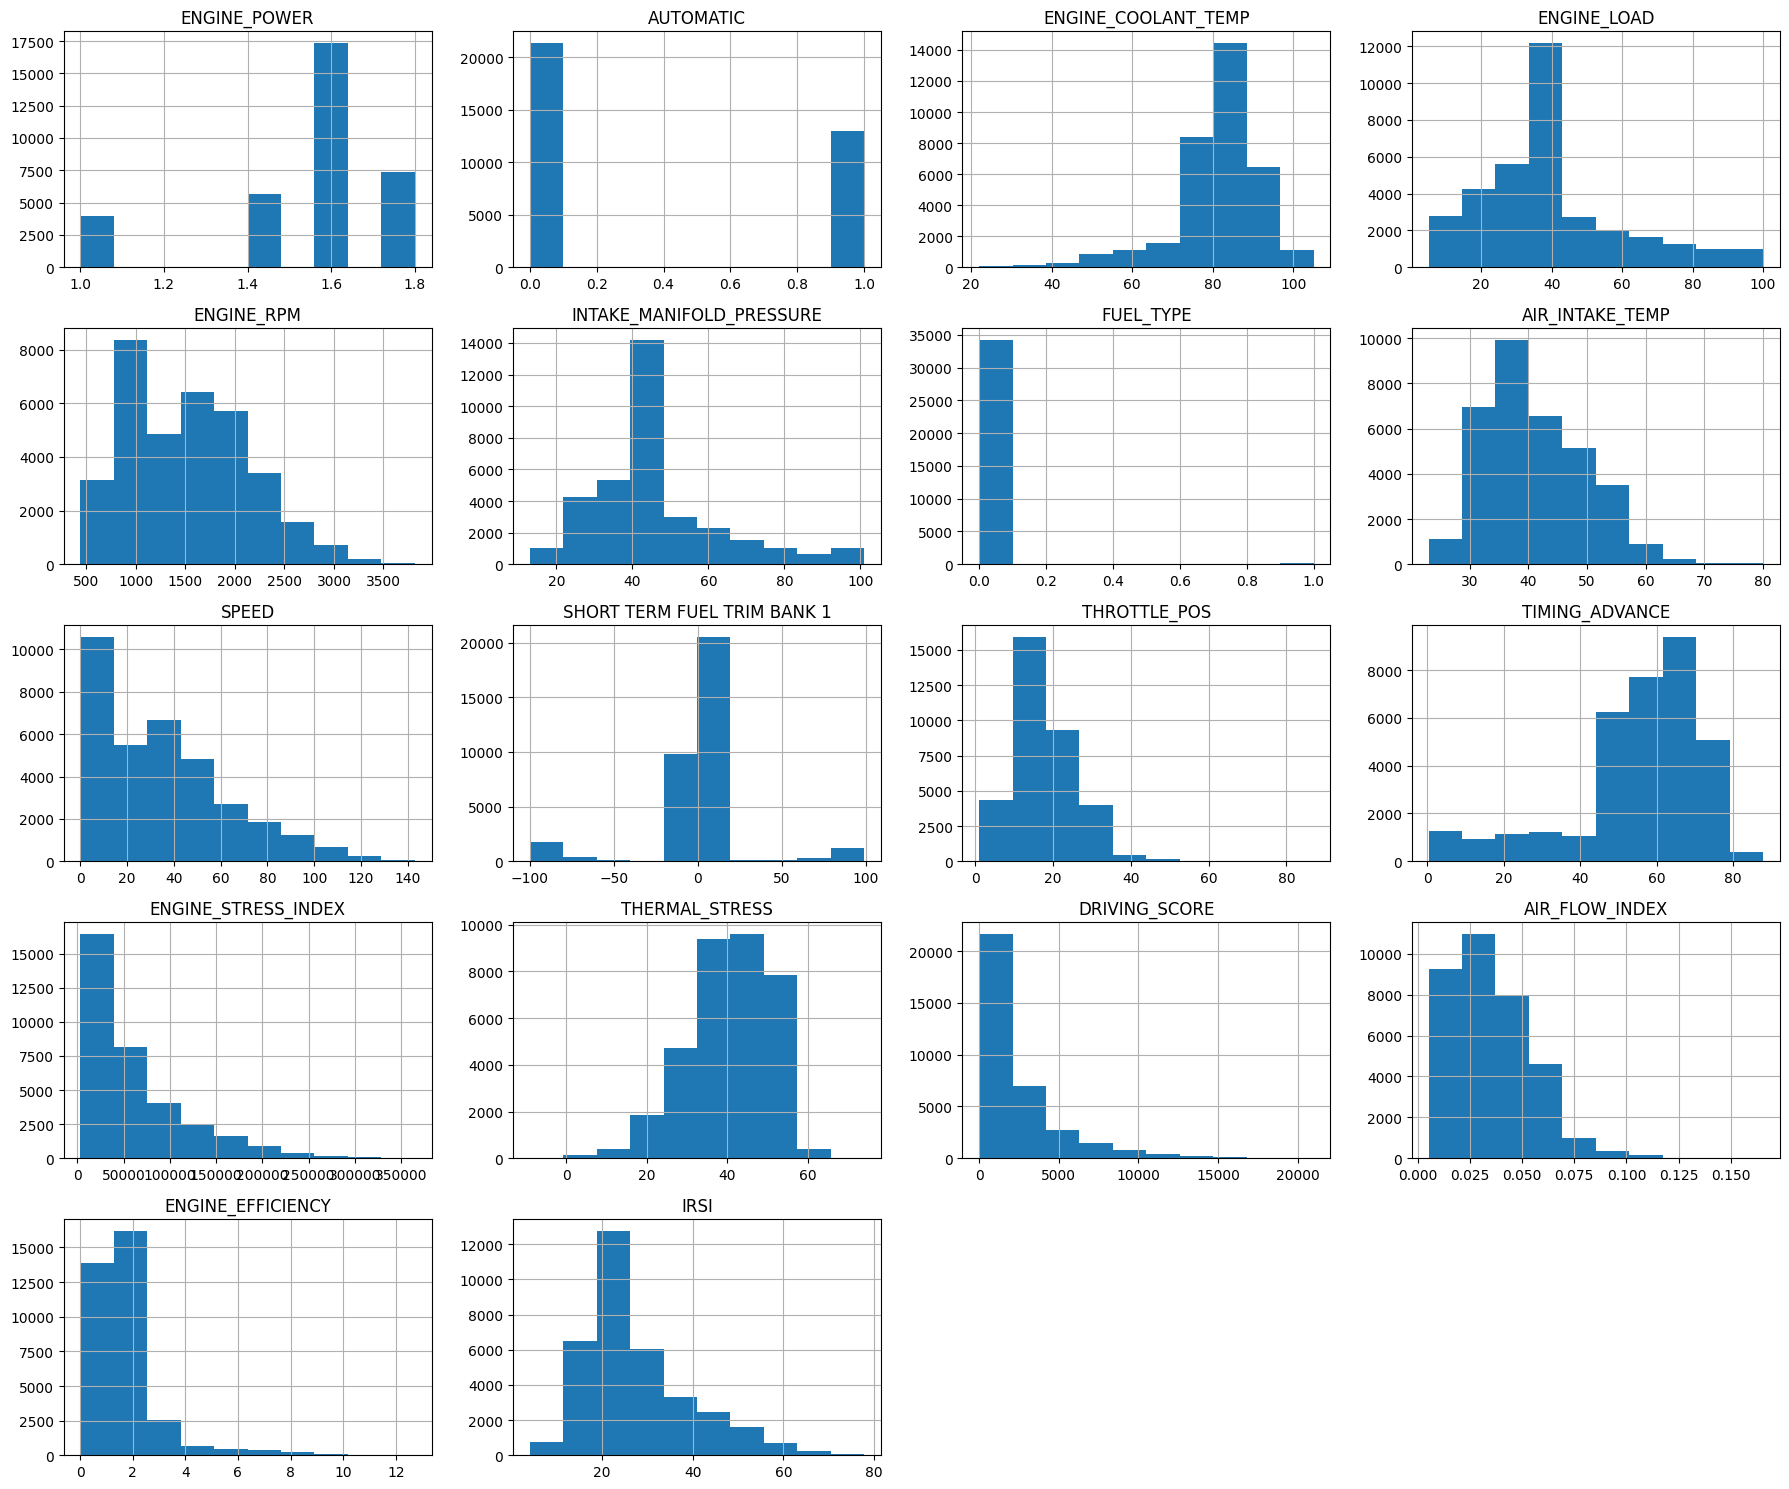

In [52]:
df2.hist(figsize=(18,15))
plt.tight_layout()
plt.show()

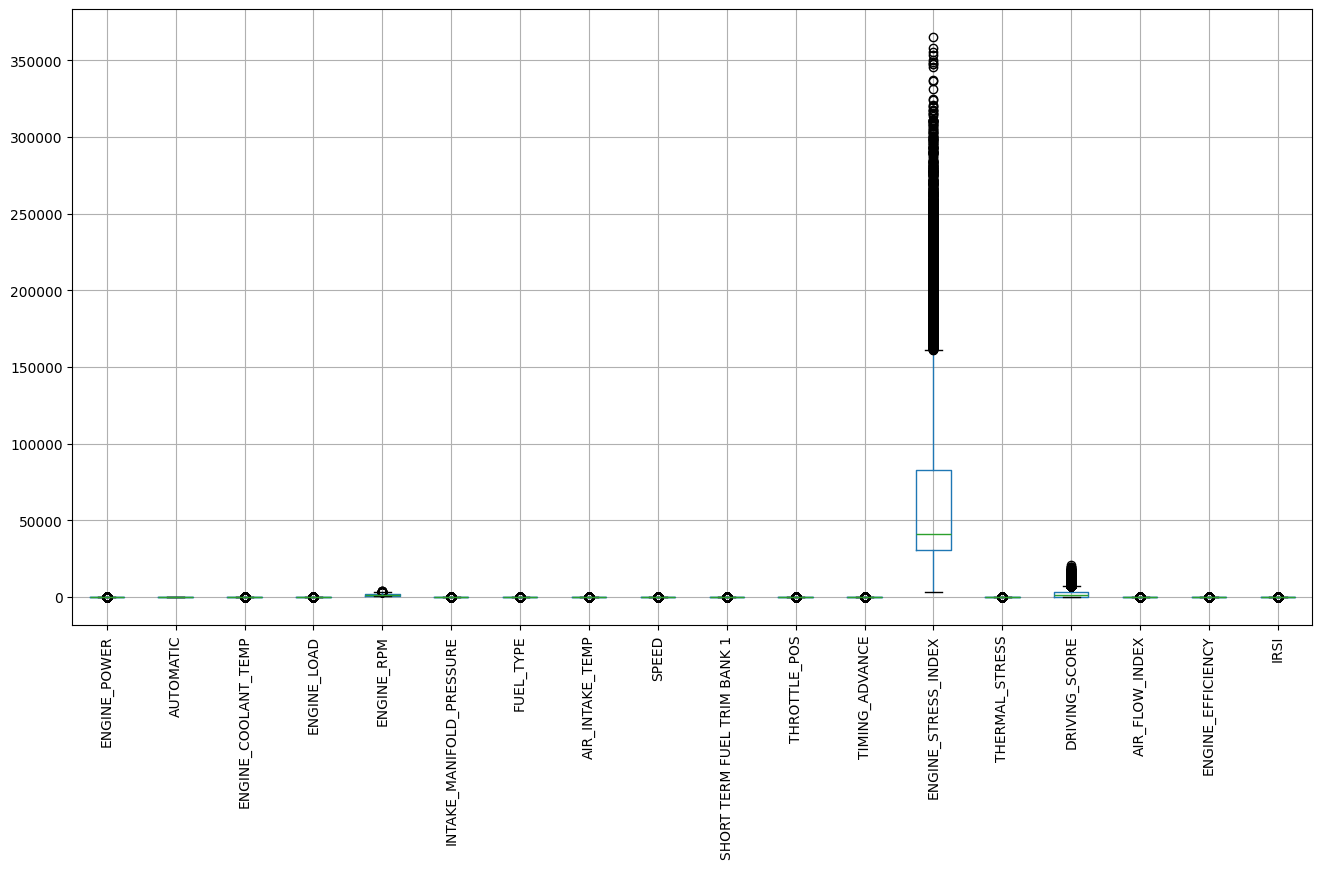

In [53]:
plt.figure(figsize=(16,8))
df2.boxplot(rot=90)
plt.show()

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_df = scaler.fit_transform(df2)

scaled_df = pd.DataFrame(
    scaled_df,
    columns=df2.columns
)

In [60]:
from google.colab import files

df2.to_csv("obd_clean.csv", index=False)
files.download("obd_clean.csv")
files.download("processed_ai4i.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#3rd Datta set opel_corsa_01.csv

In [66]:
df3=pd.read_csv("/content/opel_corsa_01.csv", sep=';')


In [68]:
df3.head()

,AltitudeVariation,VehicleSpeedInstantaneous,VehicleSpeedAverage,VehicleSpeedVariance,VehicleSpeedVariation,LongitudinalAcceleration,EngineLoad,EngineCoolantTemperature,ManifoldAbsolutePressure,EngineRPM,MassAirFlow,IntakeAirTemperature,VerticalAcceleration,FuelConsumptionAverage,roadSurface,traffic,drivingStyle
0,NaN,0,NaN,NaN,NaN,"0,0156","25,49019623",64,100,801,"7,849999905",22,"-0,0078",NaN,SmoothCondition,LowCongestionCondition,EvenPaceStyle
1,NaN,0,NaN,NaN,NaN,"0,0156","25,49019623",64,100,803,"7,889999866",22,"-0,0156",NaN,SmoothCondition,LowCongestionCondition,EvenPaceStyle
2,NaN,NaN,NaN,NaN,NaN,"0,0273","25,88235283",64,100,800,"7,769999981",22,"-0,0273",NaN,SmoothCondition,LowCongestionCondition,EvenPaceStyle
3,NaN,NaN,NaN,NaN,NaN,"0,0391","25,88235283",64,100,798,"7,769999981",22,"-0,0273",NaN,SmoothCondition,LowCongestionCondition,EvenPaceStyle
4,NaN,0,NaN,NaN,NaN,"0,0469","25,88235283",65,100,798,"7,940000057",22,"-0,0312",NaN,SmoothCondition,LowCongestionCondition,EvenPaceStyle


In [69]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7392 entries, 0 to 7391
Data columns (total 17 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   AltitudeVariation          7338 non-null   object
 1   VehicleSpeedInstantaneous  7385 non-null   object
 2   VehicleSpeedAverage        7038 non-null   object
 3   VehicleSpeedVariance       7038 non-null   object
 4   VehicleSpeedVariation      7358 non-null   object
 5   LongitudinalAcceleration   7392 non-null   object
 6   EngineLoad                 7392 non-null   object
 7   EngineCoolantTemperature   7392 non-null   int64 
 8   ManifoldAbsolutePressure   7392 non-null   int64 
 9   EngineRPM                  7392 non-null   int64 
 10  MassAirFlow                7392 non-null   object
 11  IntakeAirTemperature       7392 non-null   int64 
 12  VerticalAcceleration       7392 non-null   object
 13  FuelConsumptionAverage     7295 non-null   object
 14  roadSurf

In [70]:
df3.describe()

,EngineCoolantTemperature,ManifoldAbsolutePressure,EngineRPM,IntakeAirTemperature
count,7392.000000,7392.00000,7392.000000,7392.000000
mean,77.000947,115.72619,1560.496753,16.522321
std,8.740838,20.37355,549.154886,4.947106
min,34.000000,97.00000,752.000000,7.000000
25%,78.000000,102.00000,929.750000,12.000000
50%,80.000000,108.00000,1647.000000,16.000000
75%,81.000000,121.00000,2024.250000,19.000000
max,85.000000,252.00000,3104.000000,38.000000


In [71]:
df3.isnull().sum()

,0
AltitudeVariation,54
VehicleSpeedInstantaneous,7
VehicleSpeedAverage,354
VehicleSpeedVariance,354
VehicleSpeedVariation,34
LongitudinalAcceleration,0
EngineLoad,0
EngineCoolantTemperature,0
ManifoldAbsolutePressure,0
EngineRPM,0


In [72]:
df3.duplicated().sum()

np.int64(0)

#Convert object columns into numbers

In [73]:
df3.select_dtypes(include="object").columns

Index(['AltitudeVariation', 'VehicleSpeedInstantaneous', 'VehicleSpeedAverage',
       'VehicleSpeedVariance', 'VehicleSpeedVariation',
       'LongitudinalAcceleration', 'EngineLoad', 'MassAirFlow',
       'VerticalAcceleration', 'FuelConsumptionAverage', 'roadSurface',
       'traffic', 'drivingStyle'],
      dtype='object')

In [74]:
print(df3["roadSurface"].value_counts())

print("="*50)

print(df3["traffic"].value_counts())

print("="*50)

print(df3["drivingStyle"].value_counts())

roadSurface
SmoothCondition    7227
UnevenCondition     165
Name: count, dtype: int64
traffic
LowCongestionCondition       6815
HighCongestionCondition       449
NormalCongestionCondition     128
Name: count, dtype: int64
drivingStyle
EvenPaceStyle      6042
AggressiveStyle    1350
Name: count, dtype: int64


clean every numeric column together.

In [76]:
cols = [
    'AltitudeVariation',
    'VehicleSpeedInstantaneous',
    'VehicleSpeedAverage',
    'VehicleSpeedVariance',
    'VehicleSpeedVariation',
    'LongitudinalAcceleration',
    'EngineLoad',
    'MassAirFlow',
    'VerticalAcceleration',
    'FuelConsumptionAverage'
]

for col in cols:
    df3[col] = (
        df3[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )

    df3[col] = pd.to_numeric(df3[col], errors="coerce")

In [77]:
df3[cols].dtypes

,0
AltitudeVariation,float64
VehicleSpeedInstantaneous,float64
VehicleSpeedAverage,float64
VehicleSpeedVariance,float64
VehicleSpeedVariation,float64
LongitudinalAcceleration,float64
EngineLoad,float64
MassAirFlow,float64
VerticalAcceleration,float64
FuelConsumptionAverage,float64


In [78]:
df3.isnull().sum().sort_values(ascending=False)

,0
VehicleSpeedAverage,354
VehicleSpeedVariance,354
FuelConsumptionAverage,97
AltitudeVariation,54
VehicleSpeedVariation,34
VehicleSpeedInstantaneous,7
LongitudinalAcceleration,0
EngineCoolantTemperature,0
EngineLoad,0
ManifoldAbsolutePressure,0


#Encode the 3 categorical columns

In [79]:
# roadSurface
road_map = {
    "SmoothCondition": 0,
    "UnevenCondition": 1
}

df3["roadSurface"] = df3["roadSurface"].map(road_map)

In [81]:
# traffic
traffic_map = {
    "LowCongestionCondition": 0,
    "NormalCongestionCondition": 1,
    "HighCongestionCondition": 2
}

df3["traffic"] = df3["traffic"].map(traffic_map)

In [80]:
# drivingStyle
style_map = {
    "EvenPaceStyle": 0,
    "AggressiveStyle": 1
}

df3["drivingStyle"] = df3["drivingStyle"].map(style_map)

#Handle Missing Values

In [82]:
numeric_cols = [
    "AltitudeVariation",
    "VehicleSpeedInstantaneous",
    "VehicleSpeedAverage",
    "VehicleSpeedVariance",
    "VehicleSpeedVariation",
    "LongitudinalAcceleration",
    "EngineLoad",
    "EngineCoolantTemperature",
    "ManifoldAbsolutePressure",
    "EngineRPM",
    "MassAirFlow",
    "IntakeAirTemperature",
    "VerticalAcceleration",
    "FuelConsumptionAverage"
]

for col in numeric_cols:
    df3[col] = df3[col].fillna(df3[col].median())

In [83]:
df3.isnull().sum()

,0
AltitudeVariation,0
VehicleSpeedInstantaneous,0
VehicleSpeedAverage,0
VehicleSpeedVariance,0
VehicleSpeedVariation,0
LongitudinalAcceleration,0
EngineLoad,0
EngineCoolantTemperature,0
ManifoldAbsolutePressure,0
EngineRPM,0


Feature Engineering ⭐

Since this dataset is about road condition + driving style, let's create features that fit your project.

In [84]:
# 1. Vehicle Stress Index
df3["VehicleStressIndex"] = (
    df3["EngineLoad"] * df3["EngineRPM"]
)

In [85]:
#  2. Road Impact Score
df3["RoadImpactScore"] = (
    abs(df3["VerticalAcceleration"]) +
    abs(df3["AltitudeVariation"])
)

In [86]:
# 3. Driving Aggressiveness Score
df3["DrivingAggressiveness"] = (
    abs(df3["LongitudinalAcceleration"]) *
    df3["VehicleSpeedInstantaneous"]
)

In [87]:
# 4. Fuel Efficiency Score
df3["FuelEfficiencyScore"] = (
    df3["VehicleSpeedAverage"] /
    (df3["FuelConsumptionAverage"] + 1)
)

In [ ]:
# 5. Road Severity Index (RSI) ⭐
# This is your unique feature.

df3["RoadSeverityIndex"] = (
      0.40 * df3["roadSurface"]
    + 0.30 * df3["traffic"]
    + 0.30 * df3["drivingStyle"]
)

#EDA

In [92]:
df3.head()

,AltitudeVariation,VehicleSpeedInstantaneous,VehicleSpeedAverage,VehicleSpeedVariance,VehicleSpeedVariation,LongitudinalAcceleration,EngineLoad,EngineCoolantTemperature,ManifoldAbsolutePressure,EngineRPM,...,IntakeAirTemperature,VerticalAcceleration,FuelConsumptionAverage,roadSurface,traffic,drivingStyle,VehicleStressIndex,RoadImpactScore,DrivingAggressiveness,FuelEfficiencyScore
0,-0.300049,0.000000,28.312631,144.864363,0.0,0.0156,25.490196,64,100,801,...,22,-0.0078,15.383096,0,0,0,20417.647180,0.307849,0.000000,1.728161
1,-0.300049,0.000000,28.312631,144.864363,0.0,0.0156,25.490196,64,100,803,...,22,-0.0156,15.383096,0,0,0,20468.627573,0.315649,0.000000,1.728161
2,-0.300049,27.922319,28.312631,144.864363,0.0,0.0273,25.882353,64,100,800,...,22,-0.0273,15.383096,0,0,0,20705.882264,0.327349,0.762279,1.728161
3,-0.300049,27.922319,28.312631,144.864363,0.0,0.0391,25.882353,64,100,798,...,22,-0.0273,15.383096,0,0,0,20654.117558,0.327349,1.091763,1.728161
4,-0.300049,0.000000,28.312631,144.864363,0.0,0.0469,25.882353,65,100,798,...,22,-0.0312,15.383096,0,0,0,20654.117558,0.331249,0.000000,1.728161


In [93]:
df3.describe()

,AltitudeVariation,VehicleSpeedInstantaneous,VehicleSpeedAverage,VehicleSpeedVariance,VehicleSpeedVariation,LongitudinalAcceleration,EngineLoad,EngineCoolantTemperature,ManifoldAbsolutePressure,EngineRPM,...,IntakeAirTemperature,VerticalAcceleration,FuelConsumptionAverage,roadSurface,traffic,drivingStyle,VehicleStressIndex,RoadImpactScore,DrivingAggressiveness,FuelEfficiencyScore
count,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.00000,7392.000000,...,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000,7392.000000
mean,-0.730696,35.467037,36.321118,209.741156,-0.000609,0.127419,26.765025,77.000947,115.72619,1560.496753,...,16.522321,0.060608,15.914592,0.022321,0.138799,0.182630,42881.140390,1.716398,21.046875,2.726164
std,2.603787,32.505876,28.710737,201.257399,2.385348,0.736110,19.454573,8.740838,20.37355,549.154886,...,4.947106,0.374774,5.672862,0.147737,0.490967,0.386389,41015.354818,2.318580,27.202489,2.994109
min,-42.700012,0.000000,0.000000,0.000000,-17.789218,-2.380000,0.000000,34.000000,97.00000,752.000000,...,7.000000,-1.246000,7.271883,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.500000,8.106480,17.172789,58.794861,-0.900721,-0.348000,14.117647,78.000000,102.00000,929.750000,...,12.000000,-0.207000,12.596743,0.000000,0.000000,0.000000,19690.588775,0.556046,1.616432,0.846118
50%,-0.300049,27.922319,28.312631,144.864363,0.000000,0.109400,25.490196,80.000000,108.00000,1647.000000,...,16.000000,0.074200,15.383096,0.000000,0.000000,0.000000,26622.941766,1.186988,11.061596,1.716594
75%,0.100037,52.692120,46.469645,289.396116,0.900722,0.652000,35.294117,81.000000,121.00000,2024.250000,...,19.000000,0.312500,18.772352,0.000000,0.000000,0.000000,61458.627901,2.172953,29.036595,3.332093
max,22.400024,124.749725,121.330733,1051.789888,12.384899,2.360000,100.000000,85.000000,252.00000,3104.000000,...,38.000000,1.210000,178.876450,1.000000,2.000000,1.000000,305600.000000,42.750812,161.850368,13.318464


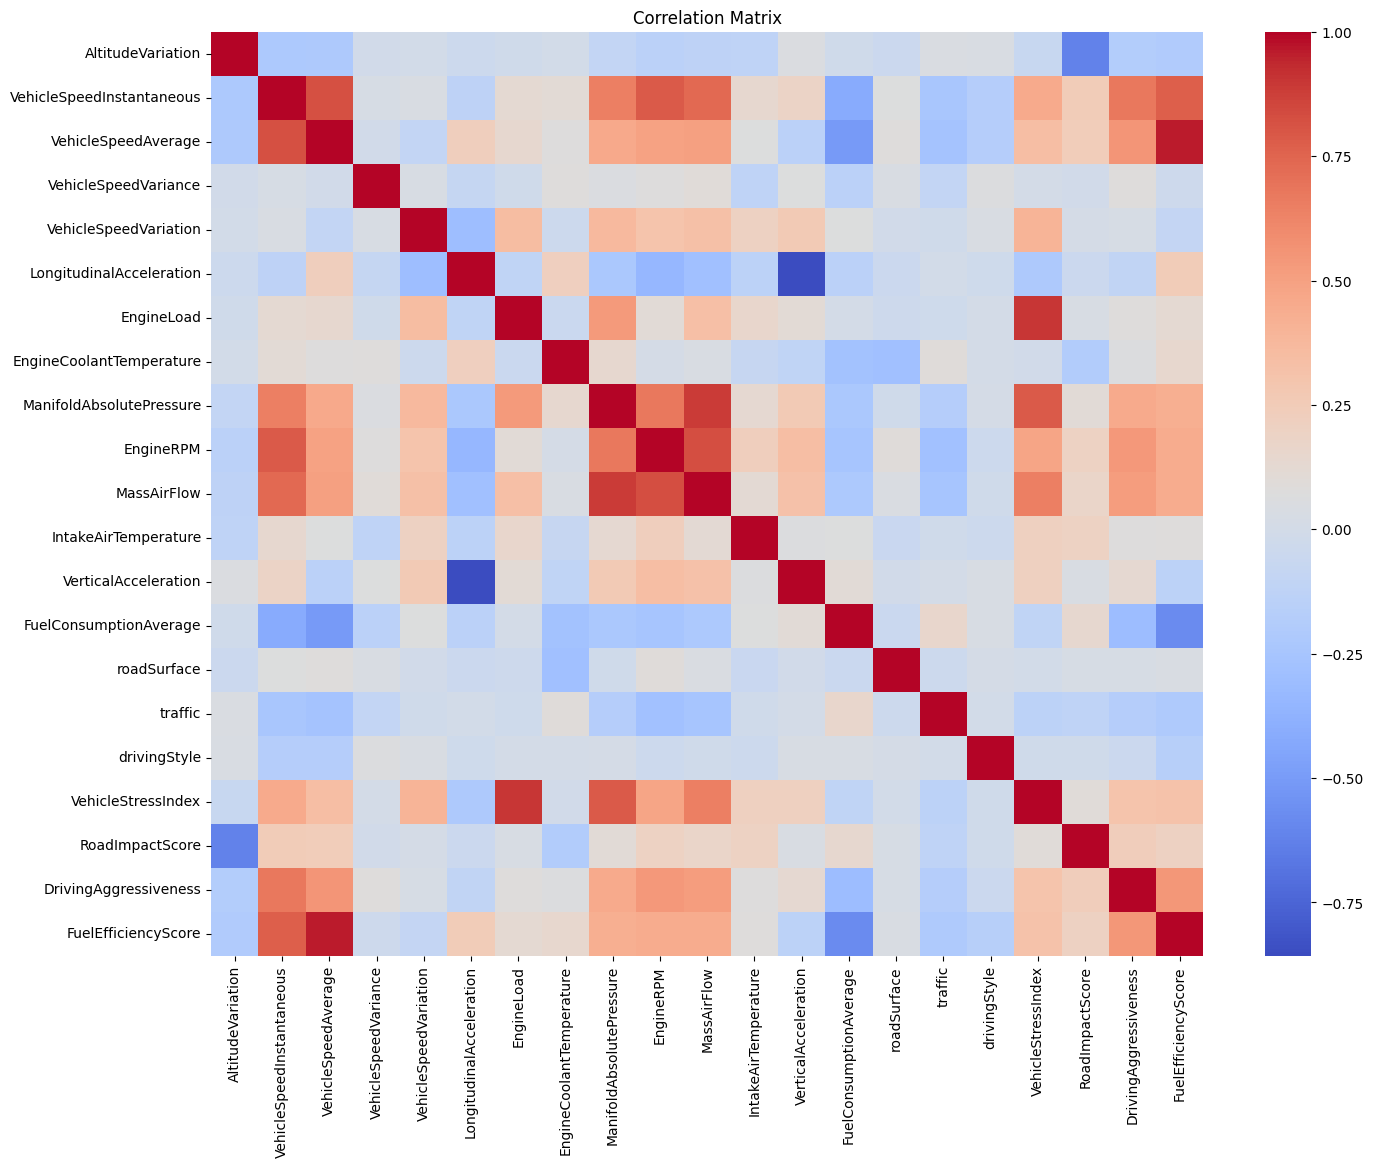

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,12))
sns.heatmap(df3.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

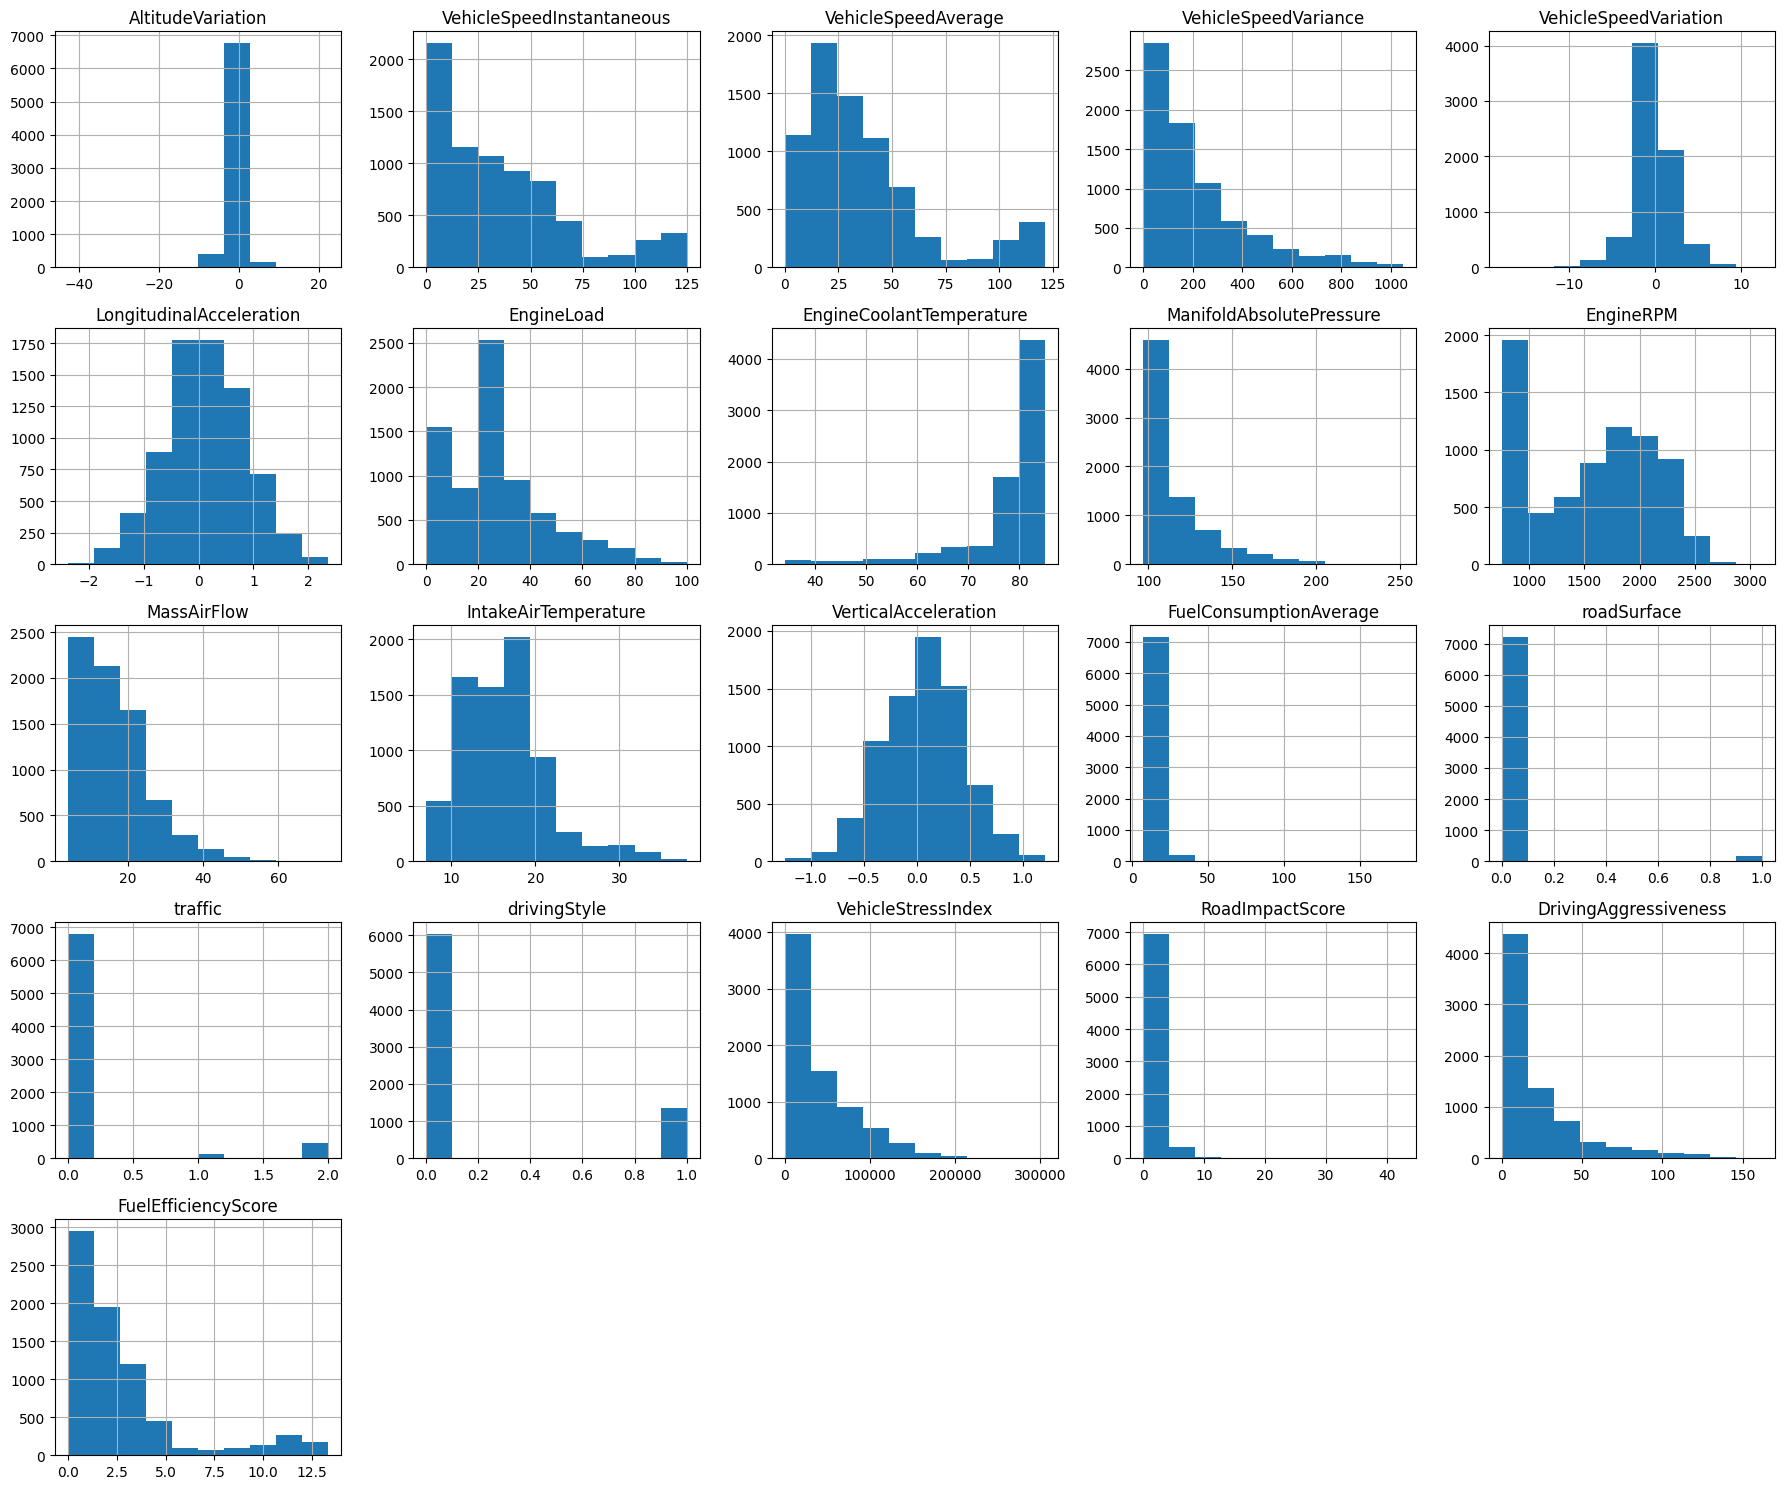

In [90]:
df3.hist(figsize=(18,15))
plt.tight_layout()
plt.show()

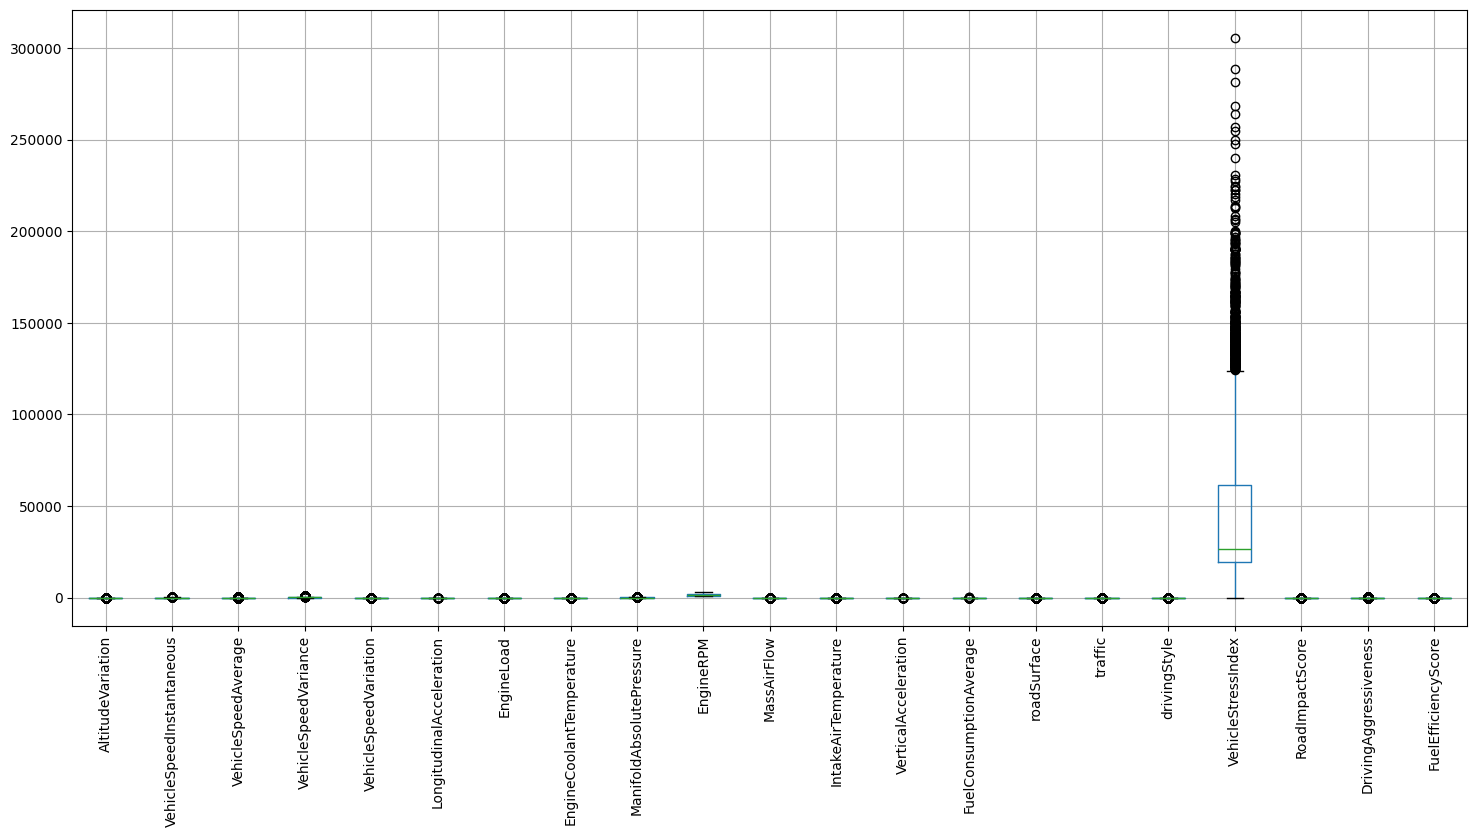

In [91]:
plt.figure(figsize=(18,8))
df3.boxplot(rot=90)
plt.show()

In [94]:
df3.to_csv("driving_behavior_clean.csv", index=False)

In [95]:
from google.colab import files
files.download("driving_behavior_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>